¿Como puedo contrarrestar el efecto en esta imagen de chaplin y monalisa?
Aplicando el Kernel Horizontal: Promedia pixeles en fila izquierda a derecha suavizando las lineas verticales mientras mas sean lo 1 y 0 mas sera la diferencia.

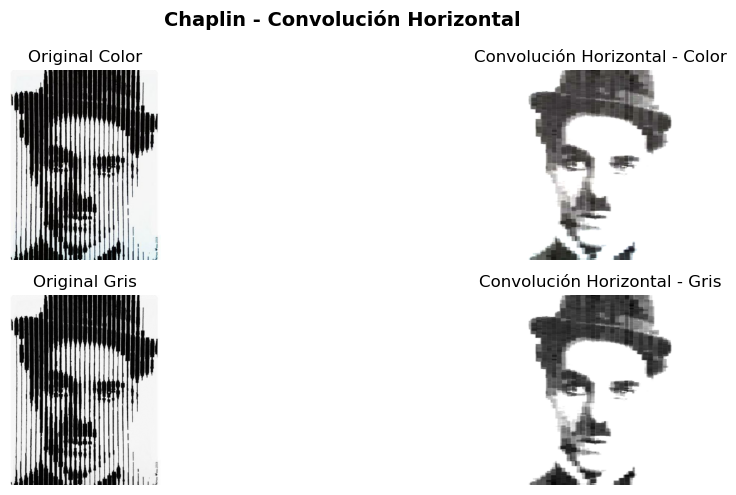

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolucion_real(imagen, kernel):
    kernel_volteado = np.flipud(np.fliplr(kernel))
    return cv2.filter2D(imagen, -1, kernel_volteado)

kernel_horizontal = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ]
], dtype=np.float32) / 5

img = cv2.imread('chaplin.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_resultado_color = convolucion_real(img_rgb, kernel_horizontal)
img_resultado_gray = convolucion_real(img_gray, kernel_horizontal)

fig = plt.figure(figsize=(14, 5))
fig.suptitle('Chaplin - Convolución Horizontal', fontsize=14, fontweight='bold')

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Color')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_resultado_color)
plt.title('Convolución Horizontal - Color')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Gris')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_resultado_gray, cmap='gray')
plt.title('Convolución Horizontal - Gris')
plt.axis('off')

plt.tight_layout()
plt.show()

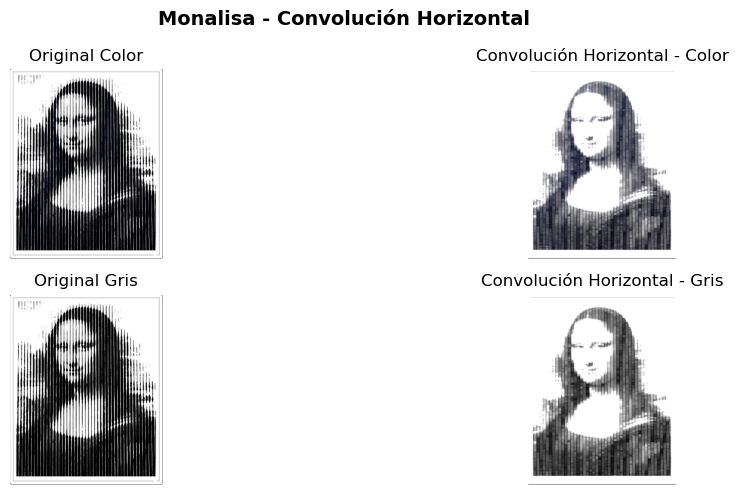

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolucion_real(imagen, kernel):
    kernel_volteado = np.flipud(np.fliplr(kernel))
    return cv2.filter2D(imagen, -1, kernel_volteado)

kernel_horizontal = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,1, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,0, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,0,],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,0, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,0, ]
], dtype=np.float32) / 5

img = cv2.imread('Monalisa.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_resultado_color = convolucion_real(img_rgb, kernel_horizontal)
img_resultado_gray = convolucion_real(img_gray, kernel_horizontal)

fig = plt.figure(figsize=(14, 5))
fig.suptitle('Monalisa - Convolución Horizontal', fontsize=14, fontweight='bold')

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Color')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_resultado_color)
plt.title('Convolución Horizontal - Color')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Gris')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_resultado_gray, cmap='gray')
plt.title('Convolución Horizontal - Gris')
plt.axis('off')

plt.tight_layout()
plt.show()

¿Como puedo contrarrestar el efecto en esta imagen del Payaso?
Usamos la formula matematica del kernel gaussiano y jugamos con los el size y el sigma hasta lograr el resultado que queremos .

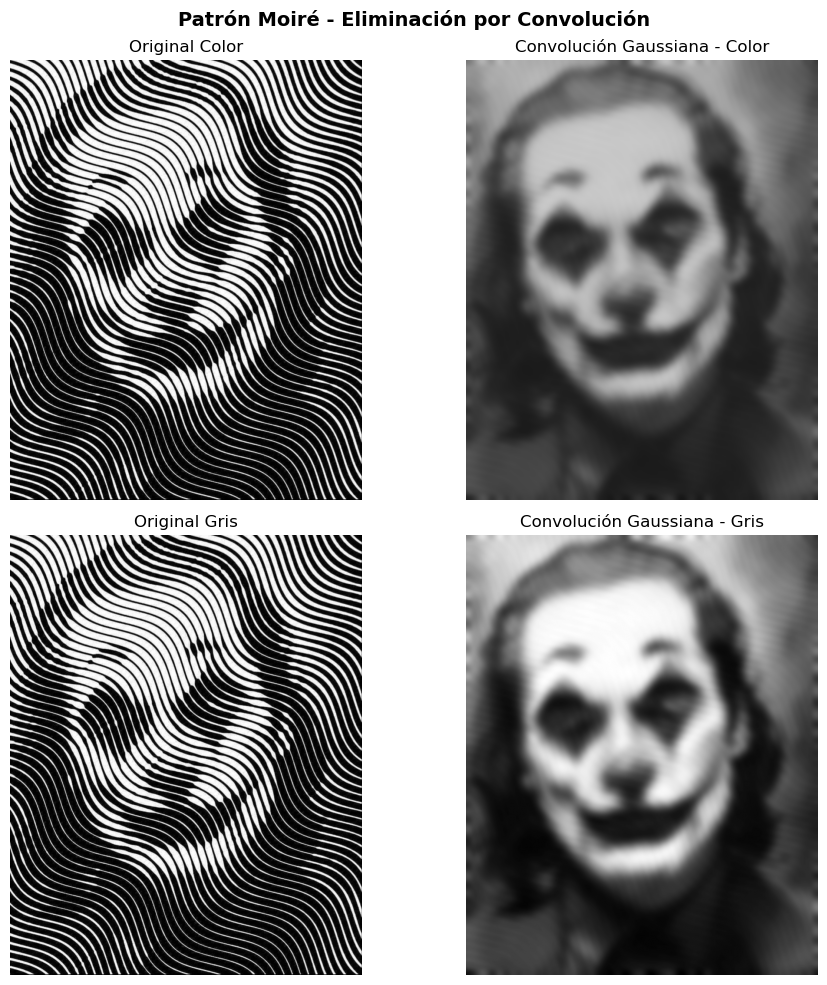

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img_color = cv2.imread('payaso.jpg')
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_gray  = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)


sigma = 9
size  = 40
ax    = np.arange(-(size//2), size//2 + 1)
xx, yy = np.meshgrid(ax, ax)
kernel_gauss = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
kernel_gauss /= kernel_gauss.sum()


def apply_kernel(image, kernel):
    if image.ndim == 3:
        channels = [cv2.filter2D(image[:,:,c], -1, kernel) for c in range(3)]
        return np.stack(channels, axis=2)
    else:
        return cv2.filter2D(image, -1, kernel)

result_color = apply_kernel(img_color, kernel_gauss)
result_gray  = apply_kernel(img_gray,  kernel_gauss)


fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Patrón Moiré - Eliminación por Convolución', fontsize=14, fontweight='bold')

axes[0, 0].imshow(img_color)
axes[0, 0].set_title('Original Color')
axes[0, 0].axis('off')

axes[0, 1].imshow(result_color)
axes[0, 1].set_title('Convolución Gaussiana - Color')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_gray, cmap='gray')
axes[1, 0].set_title('Original Gris')
axes[1, 0].axis('off')

axes[1, 1].imshow(result_gray, cmap='gray')
axes[1, 1].set_title('Convolución Gaussiana - Gris')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('moire_limpio.png', dpi=150)
plt.show()

En esta parte con ayuda de la IA lo hacemos de forma manual porque hacerlo numero por numero seria algo dificil moroso pero se lograria con tiempo. 

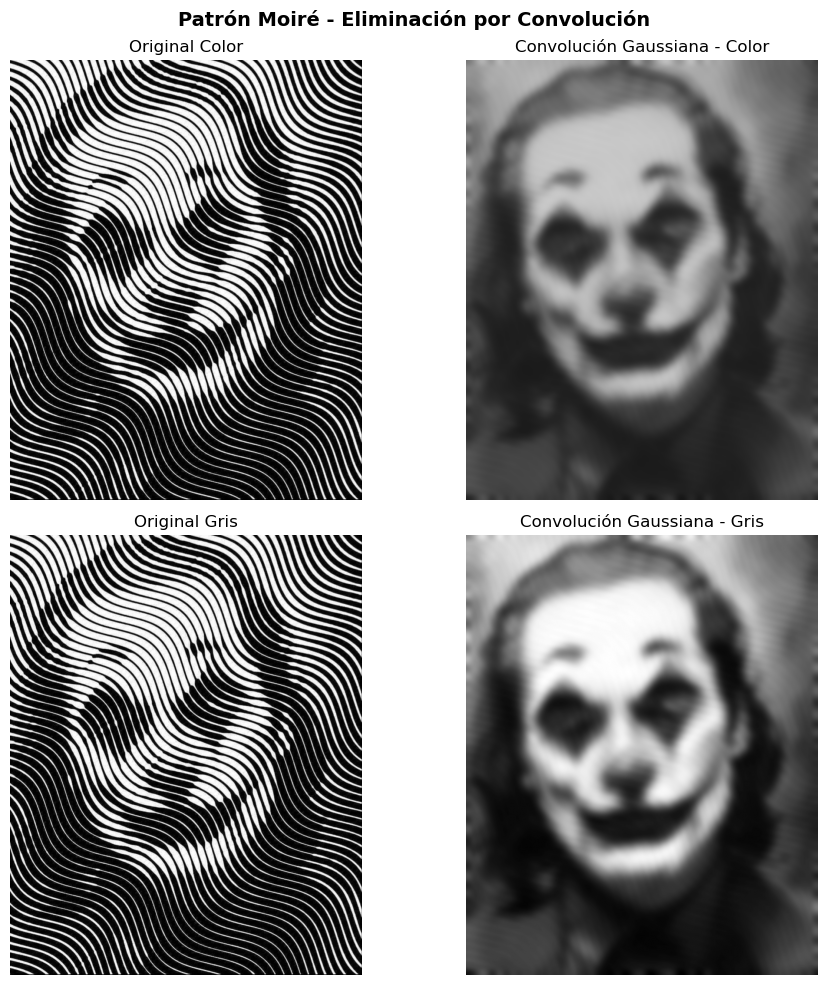

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen
img_color = cv2.imread('payaso.jpg')
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_gray  = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)

# 2. Kernel Gaussiano 41x41 escrito MANUALMENTE (sigma=9, escalado x1000000)
kernel_gauss = np.array([
    [  15,  19,  24,  29,  36,  43,  52,  61,  72,  83,  94, 106, 117, 129, 139, 149, 158, 165, 170, 173, 174, 173, 170, 165, 158, 149, 139, 129, 117, 106,  94,  83,  72,  61,  52,  43,  36,  29,  24,  19,  15],
    [  19,  24,  30,  37,  46,  55,  66,  78,  91, 105, 120, 134, 149, 164, 177, 190, 201, 210, 216, 220, 222, 220, 216, 210, 201, 190, 177, 164, 149, 134, 120, 105,  91,  78,  66,  55,  46,  37,  30,  24,  19],
    [  24,  30,  38,  47,  57,  69,  83,  98, 114, 132, 150, 169, 188, 206, 223, 239, 252, 263, 272, 277, 278, 277, 272, 263, 252, 239, 223, 206, 188, 169, 150, 132, 114,  98,  83,  69,  57,  47,  38,  30,  24],
    [  29,  37,  47,  58,  71,  86, 103, 122, 142, 164, 186, 210, 233, 255, 277, 296, 313, 327, 337, 343, 346, 343, 337, 327, 313, 296, 277, 255, 233, 210, 186, 164, 142, 122, 103,  86,  71,  58,  47,  37,  29],
    [  36,  46,  57,  71,  87, 106, 126, 149, 174, 201, 228, 257, 285, 313, 339, 363, 384, 401, 413, 421, 424, 421, 413, 401, 384, 363, 339, 313, 285, 257, 228, 201, 174, 149, 126, 106,  87,  71,  57,  46,  36],
    [  43,  55,  69,  86, 106, 128, 153, 181, 211, 243, 277, 311, 346, 379, 411, 440, 465, 485, 500, 510, 513, 510, 500, 485, 465, 440, 411, 379, 346, 311, 277, 243, 211, 181, 153, 128, 106,  86,  69,  55,  43],
    [  52,  66,  83, 103, 126, 153, 183, 216, 252, 291, 331, 372, 413, 453, 491, 526, 556, 580, 599, 610, 613, 610, 599, 580, 556, 526, 491, 453, 413, 372, 331, 291, 252, 216, 183, 153, 126, 103,  83,  66,  52],
    [  61,  78,  98, 122, 149, 181, 216, 255, 298, 343, 391, 440, 488, 536, 580, 621, 657, 686, 707, 720, 725, 720, 707, 686, 657, 621, 580, 536, 488, 440, 391, 343, 298, 255, 216, 181, 149, 122,  98,  78,  61],
    [  72,  91, 114, 142, 174, 211, 252, 298, 348, 401, 456, 513, 570, 625, 677, 725, 766, 800, 825, 840, 846, 840, 825, 800, 766, 725, 677, 625, 570, 513, 456, 401, 348, 298, 252, 211, 174, 142, 114,  91,  72],
    [  83, 105, 132, 164, 201, 243, 291, 343, 401, 462, 526, 591, 657, 720, 780, 835, 883, 922, 951, 969, 975, 969, 951, 922, 883, 835, 780, 720, 657, 591, 526, 462, 401, 343, 291, 243, 201, 164, 132, 105,  83],
    [  94, 120, 150, 186, 228, 277, 331, 391, 456, 526, 599, 673, 747, 820, 889, 951,1005,1050,1083,1103,1110,1103,1083,1050,1005, 951, 889, 820, 747, 673, 599, 526, 456, 391, 331, 277, 228, 186, 150, 120,  94],
    [ 106, 134, 169, 210, 257, 311, 372, 440, 513, 591, 673, 757, 840, 922, 999,1069,1130,1180,1217,1240,1248,1240,1217,1180,1130,1069, 999, 922, 840, 757, 673, 591, 513, 440, 372, 311, 257, 210, 169, 134, 106],
    [ 117, 149, 188, 233, 285, 346, 413, 488, 570, 657, 747, 840, 933,1024,1110,1188,1255,1311,1352,1377,1386,1377,1352,1311,1255,1188,1110,1024, 933, 840, 747, 657, 570, 488, 413, 346, 285, 233, 188, 149, 117],
    [ 129, 164, 206, 255, 313, 379, 453, 536, 625, 720, 820, 922,1024,1123,1217,1303,1377,1438,1483,1511,1520,1511,1483,1438,1377,1303,1217,1123,1024, 922, 820, 720, 625, 536, 453, 379, 313, 255, 206, 164, 129],
    [ 139, 177, 223, 277, 339, 411, 491, 580, 677, 780, 889, 999,1110,1217,1319,1412,1492,1558,1607,1637,1647,1637,1607,1558,1492,1412,1319,1217,1110, 999, 889, 780, 677, 580, 491, 411, 339, 277, 223, 177, 139],
    [ 149, 190, 239, 296, 363, 440, 526, 621, 725, 835, 951,1069,1188,1303,1412,1511,1597,1668,1720,1752,1763,1752,1720,1668,1597,1511,1412,1303,1188,1069, 951, 835, 725, 621, 526, 440, 363, 296, 239, 190, 149],
    [ 158, 201, 252, 313, 384, 465, 556, 657, 766, 883,1005,1130,1255,1377,1492,1597,1688,1763,1818,1852,1864,1852,1818,1763,1688,1597,1492,1377,1255,1130,1005, 883, 766, 657, 556, 465, 384, 313, 252, 201, 158],
    [ 165, 210, 263, 327, 401, 485, 580, 686, 800, 922,1050,1180,1311,1438,1558,1668,1763,1841,1898,1934,1946,1934,1898,1841,1763,1668,1558,1438,1311,1180,1050, 922, 800, 686, 580, 485, 401, 327, 263, 210, 165],
    [ 170, 216, 272, 337, 413, 500, 599, 707, 825, 951,1083,1217,1352,1483,1607,1720,1818,1898,1958,1995,2007,1995,1958,1898,1818,1720,1607,1483,1352,1217,1083, 951, 825, 707, 599, 500, 413, 337, 272, 216, 170],
    [ 173, 220, 277, 343, 421, 510, 610, 720, 840, 969,1103,1240,1377,1511,1637,1752,1852,1934,1995,2032,2044,2032,1995,1934,1852,1752,1637,1511,1377,1240,1103, 969, 840, 720, 610, 510, 421, 343, 277, 220, 173],
    [ 174, 222, 278, 346, 424, 513, 613, 725, 846, 975,1110,1248,1386,1520,1647,1763,1864,1946,2007,2044,2057,2044,2007,1946,1864,1763,1647,1520,1386,1248,1110, 975, 846, 725, 613, 513, 424, 346, 278, 222, 174],
    [ 173, 220, 277, 343, 421, 510, 610, 720, 840, 969,1103,1240,1377,1511,1637,1752,1852,1934,1995,2032,2044,2032,1995,1934,1852,1752,1637,1511,1377,1240,1103, 969, 840, 720, 610, 510, 421, 343, 277, 220, 173],
    [ 170, 216, 272, 337, 413, 500, 599, 707, 825, 951,1083,1217,1352,1483,1607,1720,1818,1898,1958,1995,2007,1995,1958,1898,1818,1720,1607,1483,1352,1217,1083, 951, 825, 707, 599, 500, 413, 337, 272, 216, 170],
    [ 165, 210, 263, 327, 401, 485, 580, 686, 800, 922,1050,1180,1311,1438,1558,1668,1763,1841,1898,1934,1946,1934,1898,1841,1763,1668,1558,1438,1311,1180,1050, 922, 800, 686, 580, 485, 401, 327, 263, 210, 165],
    [ 158, 201, 252, 313, 384, 465, 556, 657, 766, 883,1005,1130,1255,1377,1492,1597,1688,1763,1818,1852,1864,1852,1818,1763,1688,1597,1492,1377,1255,1130,1005, 883, 766, 657, 556, 465, 384, 313, 252, 201, 158],
    [ 149, 190, 239, 296, 363, 440, 526, 621, 725, 835, 951,1069,1188,1303,1412,1511,1597,1668,1720,1752,1763,1752,1720,1668,1597,1511,1412,1303,1188,1069, 951, 835, 725, 621, 526, 440, 363, 296, 239, 190, 149],
    [ 139, 177, 223, 277, 339, 411, 491, 580, 677, 780, 889, 999,1110,1217,1319,1412,1492,1558,1607,1637,1647,1637,1607,1558,1492,1412,1319,1217,1110, 999, 889, 780, 677, 580, 491, 411, 339, 277, 223, 177, 139],
    [ 129, 164, 206, 255, 313, 379, 453, 536, 625, 720, 820, 922,1024,1123,1217,1303,1377,1438,1483,1511,1520,1511,1483,1438,1377,1303,1217,1123,1024, 922, 820, 720, 625, 536, 453, 379, 313, 255, 206, 164, 129],
    [ 117, 149, 188, 233, 285, 346, 413, 488, 570, 657, 747, 840, 933,1024,1110,1188,1255,1311,1352,1377,1386,1377,1352,1311,1255,1188,1110,1024, 933, 840, 747, 657, 570, 488, 413, 346, 285, 233, 188, 149, 117],
    [ 106, 134, 169, 210, 257, 311, 372, 440, 513, 591, 673, 757, 840, 922, 999,1069,1130,1180,1217,1240,1248,1240,1217,1180,1130,1069, 999, 922, 840, 757, 673, 591, 513, 440, 372, 311, 257, 210, 169, 134, 106],
    [  94, 120, 150, 186, 228, 277, 331, 391, 456, 526, 599, 673, 747, 820, 889, 951,1005,1050,1083,1103,1110,1103,1083,1050,1005, 951, 889, 820, 747, 673, 599, 526, 456, 391, 331, 277, 228, 186, 150, 120,  94],
    [  83, 105, 132, 164, 201, 243, 291, 343, 401, 462, 526, 591, 657, 720, 780, 835, 883, 922, 951, 969, 975, 969, 951, 922, 883, 835, 780, 720, 657, 591, 526, 462, 401, 343, 291, 243, 201, 164, 132, 105,  83],
    [  72,  91, 114, 142, 174, 211, 252, 298, 348, 401, 456, 513, 570, 625, 677, 725, 766, 800, 825, 840, 846, 840, 825, 800, 766, 725, 677, 625, 570, 513, 456, 401, 348, 298, 252, 211, 174, 142, 114,  91,  72],
    [  61,  78,  98, 122, 149, 181, 216, 255, 298, 343, 391, 440, 488, 536, 580, 621, 657, 686, 707, 720, 725, 720, 707, 686, 657, 621, 580, 536, 488, 440, 391, 343, 298, 255, 216, 181, 149, 122,  98,  78,  61],
    [  52,  66,  83, 103, 126, 153, 183, 216, 252, 291, 331, 372, 413, 453, 491, 526, 556, 580, 599, 610, 613, 610, 599, 580, 556, 526, 491, 453, 413, 372, 331, 291, 252, 216, 183, 153, 126, 103,  83,  66,  52],
    [  43,  55,  69,  86, 106, 128, 153, 181, 211, 243, 277, 311, 346, 379, 411, 440, 465, 485, 500, 510, 513, 510, 500, 485, 465, 440, 411, 379, 346, 311, 277, 243, 211, 181, 153, 128, 106,  86,  69,  55,  43],
    [  36,  46,  57,  71,  87, 106, 126, 149, 174, 201, 228, 257, 285, 313, 339, 363, 384, 401, 413, 421, 424, 421, 413, 401, 384, 363, 339, 313, 285, 257, 228, 201, 174, 149, 126, 106,  87,  71,  57,  46,  36],
    [  29,  37,  47,  58,  71,  86, 103, 122, 142, 164, 186, 210, 233, 255, 277, 296, 313, 327, 337, 343, 346, 343, 337, 327, 313, 296, 277, 255, 233, 210, 186, 164, 142, 122, 103,  86,  71,  58,  47,  37,  29],
    [  24,  30,  38,  47,  57,  69,  83,  98, 114, 132, 150, 169, 188, 206, 223, 239, 252, 263, 272, 277, 278, 277, 272, 263, 252, 239, 223, 206, 188, 169, 150, 132, 114,  98,  83,  69,  57,  47,  38,  30,  24],
    [  19,  24,  30,  37,  46,  55,  66,  78,  91, 105, 120, 134, 149, 164, 177, 190, 201, 210, 216, 220, 222, 220, 216, 210, 201, 190, 177, 164, 149, 134, 120, 105,  91,  78,  66,  55,  46,  37,  30,  24,  19],
    [  15,  19,  24,  29,  36,  43,  52,  61,  72,  83,  94, 106, 117, 129, 139, 149, 158, 165, 170, 173, 174, 173, 170, 165, 158, 149, 139, 129, 117, 106,  94,  83,  72,  61,  52,  43,  36,  29,  24,  19,  15]
], dtype=np.float32)

# Normalizar
kernel_gauss /= kernel_gauss.sum()

# 3. Aplicar kernel canal por canal
def apply_kernel(image, kernel):
    if image.ndim == 3:
        channels = [cv2.filter2D(image[:,:,c], -1, kernel) for c in range(3)]
        return np.stack(channels, axis=2)
    else:
        return cv2.filter2D(image, -1, kernel)

result_color = apply_kernel(img_color, kernel_gauss)
result_gray  = apply_kernel(img_gray,  kernel_gauss)

# 4. Mostrar resultados
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Patrón Moiré - Eliminación por Convolución', fontsize=14, fontweight='bold')

axes[0, 0].imshow(img_color)
axes[0, 0].set_title('Original Color')
axes[0, 0].axis('off')

axes[0, 1].imshow(result_color)
axes[0, 1].set_title('Convolución Gaussiana - Color')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_gray, cmap='gray')
axes[1, 0].set_title('Original Gris')
axes[1, 0].axis('off')

axes[1, 1].imshow(result_gray, cmap='gray')
axes[1, 1].set_title('Convolución Gaussiana - Gris')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('moire_limpio.png', dpi=150)
plt.show()